<a href="https://colab.research.google.com/github/jyryu3161/LAIDD_metabolicmodeling/blob/main/lec03_%E1%84%89%E1%85%B5%E1%86%AF%E1%84%89%E1%85%B3%E1%86%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q --upgrade "cobra>=0.31.1" hopsy swiglpk

# Loading a model and inspecting it

In [3]:
import cobra
from cobra.io import load_model

# "iJO1366" and "salmonella" are also valid arguments
model = load_model("textbook")

In [4]:
model

Name,e_coli_core
Memory address,791f5c2b1910
Number of metabolites,72
Number of reactions,95
Number of genes,137
Number of groups,0
Objective expression,1.0*Biomass_Ecoli_core - 1.0*Biomass_Ecoli_core_reverse_2cdba
Compartments,"cytosol, extracellular"


In [5]:
print(len(model.reactions))
print(len(model.metabolites))
print(len(model.genes))

95
72
137


## Running pFBA

In [6]:
model.objective = 'Biomass_Ecoli_core'
fba_solution = model.optimize()
pfba_solution = cobra.flux_analysis.pfba(model)



# Simulating Deletions

In [2]:
import pandas
from time import time

from cobra.io import load_model
from cobra.flux_analysis import (
    single_gene_deletion, single_reaction_deletion, double_gene_deletion,
    double_reaction_deletion)

# (A or B) -> R

cobra_model = load_model("textbook")
ecoli_model = load_model("iJO1366")



## Knocking out single genes and reactions

In [8]:
print('complete model: ', cobra_model.optimize())
with cobra_model:
    cobra_model.reactions.PFK.knock_out()
    print('pfk knocked out: ', cobra_model.optimize())




complete model:  <Solution 0.874 at 0x791f5aed2570>
pfk knocked out:  <Solution 0.704 at 0x791f5aed0f50>


In [9]:
print('complete model: ', cobra_model.optimize())
with cobra_model:
    cobra_model.genes.b1723.knock_out()
    print('pfkA knocked out: ', cobra_model.optimize())
    cobra_model.genes.b3916.knock_out()
    print('pfkB knocked out: ', cobra_model.optimize())

# X

complete model:  <Solution 0.874 at 0x791f5ad05400>
pfkA knocked out:  <Solution 0.874 at 0x791f5aed1490>
pfkB knocked out:  <Solution 0.704 at 0x791f5aed05f0>


## MOMA

In [12]:
from cobra.io import load_model
from cobra.flux_analysis.moma import moma
from cobra.flux_analysis.room import room  # ROOM도 같이 예시

# 1) WT 모델과 WT FBA 해 구하기
model = load_model("textbook")
wt_solution = model.optimize()           # <- 참조 flux (Solution)

# 2) KO 모델 만들기
ko_model = model.copy()
ko_model.genes.get_by_id("b1723").knock_out()
ko_model.genes.get_by_id("b3916").knock_out()

# 3) MOMA (변이 모델 vs WT flux 참조)
# QP 솔버가 없으면 linear=True로 선형화 버전 사용
sol_moma = moma(ko_model, wt_solution, linear=True)          # 기본: quadratic MOMA
# sol_moma = moma(ko_model, wt_solution, linear=True)  # QP 솔버 없을 때

for each_reaction in sol_moma.fluxes.index:
    print(each_reaction, sol_moma.fluxes[each_reaction])


ACALD 0.0
ACALDt 0.0
ACKr 0.0
ACONTa 3.5031463318650666
ACONTb 3.5031463318650666
ACt2r 0.0
ADK1 1.7581774441068039
AKGDH 3.50314633186507
AKGt2r 0.0
ALCD2x 0.0
ATPM 52.440179248999875
ATPS4r 49.91983522907707
Biomass_Ecoli_core 0.0
CO2t -21.018877991190358
CS 3.5031463318650666
CYTBD 42.0377559823807
D_LACt2 0.0
ENO 3.5031463318650538
ETOHt2r 0.0
EX_ac_e 0.0
EX_acald_e 0.0
EX_akg_e 0.0
EX_co2_e 21.018877991190358
EX_etoh_e 0.0
EX_for_e 0.0
EX_fru_e 0.0
EX_fum_e 0.0
EX_glc__D_e -3.5031463318650538
EX_gln__L_e 0.0
EX_glu__L_e 0.0
EX_h_e 4.446055959867588e-15
EX_h2o_e 21.01887799119028
EX_lac__D_e 0.0
EX_mal__L_e 0.0
EX_nh4_e -3.0690851443077716e-16
EX_o2_e -21.01887799119035
EX_pi_e 1.1001888274971144e-14
EX_pyr_e 0.0
EX_succ_e 0.0
FBA 0.0
FBP 0.0
FORt2 0.0
FORti 0.0
FRD7 0.0
FRUpts2 0.0
FUM 3.50314633186507
FUMt2_2 0.0
G6PDH2r 10.509438995595154
GAPD 3.5031463318650533
GLCpts 3.5031463318650538
GLNS 0.22346172933182734
GLNabc 0.0
GLUDy 2.553088876716449e-15
GLUN 0.22346172933182734
GLU

## ROOM

In [ ]:
from cobra.io import load_model
from cobra.flux_analysis.moma import moma
from cobra.flux_analysis.room import room  # ROOM도 같이 예시

# 1) WT 모델과 WT FBA 해 구하기
model = load_model("textbook")
wt_solution = model.optimize()           # <- 참조 flux (Solution)

# 2) KO 모델 만들기
ko_model = model.copy()
ko_model.genes.get_by_id("b0351").knock_out()

# 4) ROOM (역시 WT flux를 참조로 사용)
sol_room = room(ko_model, wt_solution, delta=1e-6, epsilon=1e-6)
print("ROOM growth:", sol_room.objective_value)
print(sol_room.fluxes)



## Single Deletions

In [3]:
from cobra.io import load_model

cobra_model = load_model("textbook")

deletion_results = single_gene_deletion(cobra_model)
deletion_results

,ids,growth,status
0,{b1723},8.739215e-01,optimal
1,{b1241},8.739215e-01,optimal
2,{b2284},2.116629e-01,optimal
3,{b3493},8.739215e-01,optimal
4,{b2288},2.116629e-01,optimal
...,...,...,...
132,{b2987},8.739215e-01,optimal
133,{b1818},8.739215e-01,optimal
134,{b3738},3.742299e-01,optimal
135,{b0720},6.835346e-17,optimal


In [4]:
single_gene_deletion(cobra_model, cobra_model.genes[:20])


,ids,growth,status
0,{b1241},0.873922,optimal
1,{b0118},0.873922,optimal
2,{b0351},0.873922,optimal
3,{b0727},0.858307,optimal
4,{b0116},0.782351,optimal
5,{b1849},0.873922,optimal
6,{b3734},0.374230,optimal
7,{b1276},0.873922,optimal
8,{b2587},0.873922,optimal
9,{b3732},0.374230,optimal


In [5]:
single_reaction_deletion(cobra_model, cobra_model.reactions[:20])


,ids,growth,status
0,{ACONTb},0.000000e+00,optimal
1,{ENO},-7.624485e-16,optimal
2,{Biomass_Ecoli_core},0.000000e+00,optimal
3,{CO2t},4.616696e-01,optimal
4,{ACALD},8.739215e-01,optimal
5,{D_LACt2},8.739215e-01,optimal
6,{ADK1},8.739215e-01,optimal
7,{EX_ac_e},8.739215e-01,optimal
8,{ATPM},9.166475e-01,optimal
9,{ALCD2x},8.739215e-01,optimal


# 대사공학 응용

0.8739215069684271
0.0


 33%|███▎      | 45/137 [00:13<00:23,  3.98it/s]/usr/local/lib/python3.12/dist-packages/cobra/util/solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)
100%|██████████| 137/137 [00:41<00:00,  3.32it/s]

      gene    growth     succinate
126  b0722  0.506593  5.311059e+00
128  b0721  0.506593  5.311059e+00
127  b0724  0.506593  5.311059e+00
129  b0723  0.506593  5.311059e+00
62   b1761  0.817771  5.289988e-17


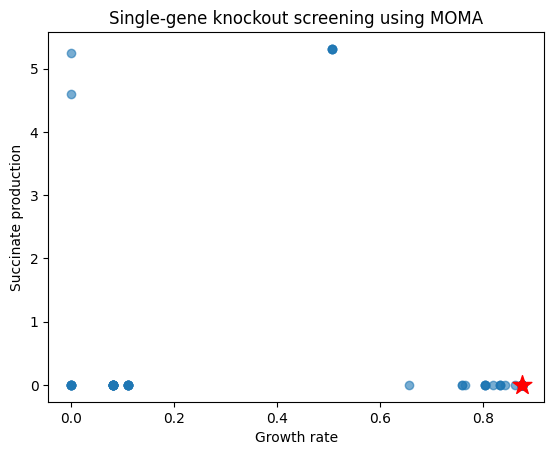

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

from cobra.io import load_model
from cobra.flux_analysis import pfba
from cobra.flux_analysis.moma import moma

import tqdm

# 1. 모델과 WT flux 계산
model = load_model("textbook")
model.objective = "Biomass_Ecoli_core"

wt = pfba(model)
wt_growth = wt.fluxes["Biomass_Ecoli_core"]
wt_succinate = wt.fluxes["EX_succ_e"]

print(wt_growth)
print(wt_succinate)

# 2. 단일 유전자 결실 후 MOMA 수행
results = []

for gene in tqdm.tqdm(model.genes):
    mutant = model.copy()
    mutant.genes.get_by_id(gene.id).knock_out()

    solution = moma(mutant, solution=wt, linear=True)

    results.append({
        "gene": gene.id,
        "growth": solution.fluxes["Biomass_Ecoli_core"],
        "succinate": solution.fluxes["EX_succ_e"]
    })


# 3. 증산 후보 정리
df = pd.DataFrame(results)

candidates = df[
    (df["growth"] >= wt_growth * 0.1) &
    (df["succinate"] > wt_succinate)
].sort_values("succinate", ascending=False)

print(candidates.head(10))


# 4. 결과 시각화
plt.scatter(df["growth"], df["succinate"], alpha=0.6)
plt.scatter(wt_growth, wt_succinate, marker="*", s=200, color="red")

plt.xlabel("Growth rate")
plt.ylabel("Succinate production")
plt.title("Single-gene knockout screening using MOMA")
plt.show()